In [ ]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from types import NoneType

def predict_and_evaluate(model, features, labels, threeshold = 0.5):

  pred_proba = model.predict(features)
  pred_positive = pred_proba[:, 1]
  pred = np.where(pred_positive > threeshold, 1, 0)
  if type(labels) != NoneType:
    bal_acc = balanced_accuracy_score(labels, pred)

    print('=='*10)
    print(f'Balanced Accuracy: {bal_acc}')
    print('=='*10)

    report = classification_report(labels, pred, zero_division=0)
    print(report)
    plot_confusion_matrix(labels, pred, ['benigna', 'maligna'], 2)


    return pred_proba, pred, bal_acc, report
  else:
    return pred_proba, pred

In [ ]:
def plot_roc_curve(true: np.ndarray, pred: np.ndarray):
    prob_positive = pred[:, 1]

    fpr, tpr, thresholds = roc_curve(true, prob_positive)
    roc_auc = auc(fpr, tpr)

    j_scores = tpr - fpr
    j_index = np.argmax(j_scores)

    optimal_threshold = thresholds[j_index]
    plt.figure(figsize=(8, 6))

    # Curva do Modelo
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Curva ROC (AUC = {roc_auc:.4f})')

    # Linha de classificação aleatória
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')

    # Ponto do threshold ideal
    plt.plot(fpr[j_index], tpr[j_index], 'ro', markersize=8,
             label=f'Threshold Ideal ({optimal_threshold:.4f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.title('Curva ROC e Threshold Ótimo para Classificador de Melanoma')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return optimal_threshold, roc_auc

In [ ]:
IMAGE_SIZE = (224, 224)

def load_and_preprocess(file_path, label):
    """
    Função para carregar a aplicar pré processamento básico em uma imagem.
    Transformação da imagem em tensor e redimensionamento.
    """
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)

    # EfficientNet espera pixels entre [0, 255], então APENAS converta para float
    image = tf.cast(image, tf.float32)

    return image, label

In [ ]:
def load_and_preprocess_test(file_path):
    """
    Função para carregar a aplicar pré processamento básico em uma imagem.
    Transformação da imagem em tensor e redimensionamento.
    """
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)

    # EfficientNet espera pixels entre [0, 255], então APENAS converta para float
    image = tf.cast(image, tf.float32)
    # image = tf.cast(image, tf.float32) / 255.0

    return image

In [ ]:

def augment_data(image, label):
    """
    Função que aplica transformações aleatórias (Data Augmentation) na imagem.
    """
    # Flips e transformações de cor
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image, label


In [ ]:
BATCH_SIZE = 128
BASE_DIR = '/content/drive/MyDrive/MDC_data/images/'

In [ ]:
# Carregamento o dataframe de rótulos e criação do conjunto de dados como
# Dataset para obter performance otimizada de processamento

train_info = pd.read_csv("/content/drive/MyDrive/MDC_data/train.csv")

train_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in train_info['path']]

y_train = train_info['target'].values

train_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(train_file_paths), tf.constant(y_train)))
train_images_ds = train_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)
train_images_ds_augmented = train_images_ds.shuffle(buffer_size=1024).map(
    augment_data,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_batches = train_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
train_batches_augmented = train_images_ds_augmented.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
val_info = pd.read_csv("/content/drive/MyDrive/MDC_data/val.csv")

val_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in val_info['path']]

y_val = val_info['target'].values

val_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(val_file_paths), tf.constant(y_val)))
val_images_ds = val_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

val_batches = val_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names, NUM_CLASSES=4):
  cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))).astype("float")
  cm = cm / cm.sum(axis=1, keepdims=True)

  plt.figure(figsize=(6,5))
  sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=True,
        linewidths=.5,
        linecolor='black'
    )

  plt.title("Matriz de Confusão Normalizada")
  ticks = np.arange(NUM_CLASSES)
  plt.xticks(ticks + 0.5, class_names, rotation=45, ha="right")
  plt.yticks(ticks + 0.5, class_names, rotation=0)
  plt.ylabel("Verdadeiro")
  plt.xlabel("Predito")
  plt.tight_layout()
  plt.show()

In [ ]:
classes = np.unique(y_train)


weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

In [ ]:
# base_model = tf.keras.applications.ResNet50(weights = 'imagenet', include_top = False, input_shape = (224, 224, 3))
base_model = tf.keras.applications.EfficientNetB0(weights ='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model.trainable = True
# 2. CONGELAR completamente a base (Feature Extraction puro)
# base_model.trainable = False

# Congelamento de todas camadas
#for layer in model.layers:
#    layer.trainable = False
# #Congelamento de n camadas
for layer in base_model.layers[:-40]:
    layer.trainable = False

model = tf.keras.Sequential([base_model,
                              tf.keras.layers.GlobalAveragePooling2D(),
                              Dropout(rate=0.3),
                              Dense(2, activation = 'softmax')])

input_shape = (None, 224, 224, 3)
model.build(input_shape=input_shape)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,053,266 (7.83 MB)

 Non-trainable params: 1,998,867 (7.63 MB)

In [ ]:
import keras

#SGD
sgd = tf.keras.optimizers.SGD(learning_rate = 0.001, momentum = 0.9, decay = 0.001)

#Adam
learning_rate = 1e-4 # Uso de baixa taxa de aprendizado
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

#Early stopping
early = tf.keras.callbacks.EarlyStopping (monitor = 'val_loss', patience = 5, restore_best_weights = True)
f1_score = keras.metrics.F1Score(average = 'macro')

# Compila o modelo (assumindo que 'frozen_model' está definido).
model.compile (loss = 'sparse_categorical_crossentropy', optimizer = optimizer, metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [ ]:
n_epochs = 20
model.fit(train_batches_augmented,
          epochs = n_epochs,
          class_weight = class_weights,
          validation_data = val_batches,
          callbacks=[early])


Epoch 1/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 82s 327ms/step - accuracy: 0.6432 - loss: 0.6073 - val_accuracy: 0.7256 - val_loss: 0.5173
Epoch 2/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 171ms/step - accuracy: 0.7660 - loss: 0.4622 - val_accuracy: 0.7656 - val_loss: 0.4805
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 29s 173ms/step - accuracy: 0.7997 - loss: 0.4118 - val_accuracy: 0.7736 - val_loss: 0.4660
Epoch 4/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 169ms/step - accuracy: 0.8190 - loss: 0.3712 - val_accuracy: 0.7960 - val_loss: 0.4200
Epoch 5/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 170ms/step - accuracy: 0.8391 - loss: 0.3433 - val_accuracy: 0.8096 - val_loss: 0.4025
Epoch 6/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 29s 172ms/step - accuracy: 0.8583 - loss: 0.3079 - val_accuracy: 0.8168 - val_loss: 0.3849
Epoch 7/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 29s 172ms/step - accuracy: 0.8703 - loss: 0.2848 - val_accuracy: 0.8176 - val_loss: 0.3956
Epoch 8/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 171ms/step - accuracy: 0.8788 - loss: 0

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 476ms/step
Balanced Accuracy: 0.825598247387934
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      2070
           1       0.59      0.76      0.66       430

    accuracy                           0.87      2500
   macro avg       0.77      0.83      0.79      2500
weighted avg       0.89      0.87      0.87      2500



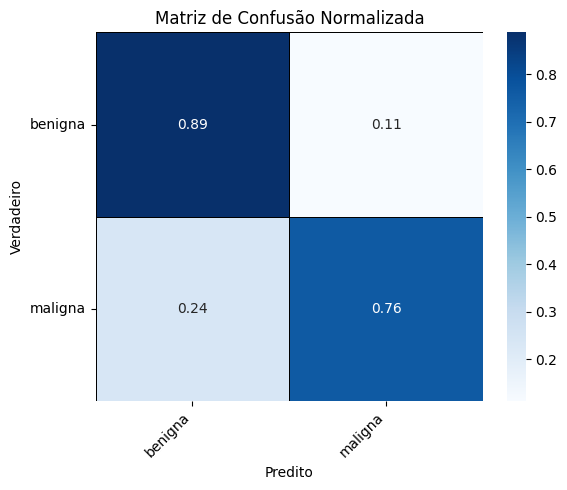

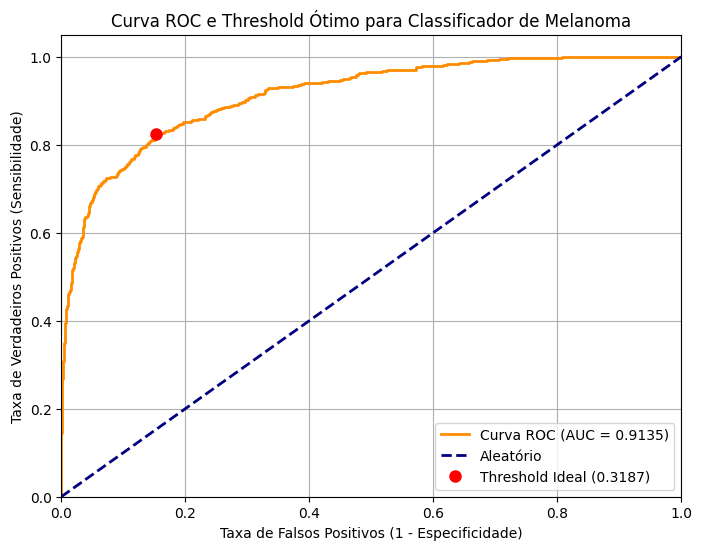

In [ ]:
val_pred_proba, val_pred, val_bal_acc, val_report = predict_and_evaluate(model, val_batches, y_val)
optimal_threshold, roc_auc = plot_roc_curve(y_val, val_pred_proba)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step
Balanced Accuracy: 0.8343781597573307
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      2070
           1       0.53      0.82      0.64       430

    accuracy                           0.84      2500
   macro avg       0.74      0.83      0.77      2500
weighted avg       0.88      0.84      0.86      2500



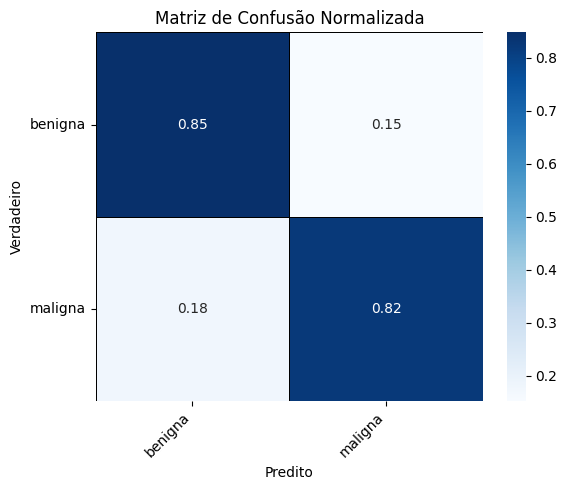

In [ ]:
val_pred_proba, val_pred, val_bal_acc, val_report = predict_and_evaluate(model, val_batches, y_val, optimal_threshold)

In [ ]:
import os
import glob
import pandas as pd
import tensorflow as tf
from datetime import datetime

# Diretório das imagens de teste
TEST_DIR = BASE_DIR + '/images/test/'
SAVE_DIR = os.path.join(os.path.dirname(BASE_DIR.rstrip('/')), 'effnetb0_models_submissions')

# Listar todos os arquivos de imagem no diretório
test_file_paths = sorted(glob.glob(os.path.join(TEST_DIR, '*.jpg')))

# Criar a lista de IDs para a submissão ('images/test/NOME_DO_ARQUIVO.jpg')
submission_ids = [f"images/test/{os.path.basename(path)}" for path in test_file_paths]

# Organizar os batches de teste
test_path_ds = tf.data.Dataset.from_tensor_slices(test_file_paths)
test_images_ds = test_path_ds.map(load_and_preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
test_batches = test_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Usar a funcao para retornar as probabilidades e as predições
test_proba, test_pred = predict_and_evaluate(model, test_batches, None, optimal_threshold)

# Colocar predições em um df com os ids ('images/test/NOME_DO_ARQUIVO.jpg')
submission_df = pd.DataFrame({
    'ID': submission_ids,
    'TARGET': test_pred
})

# Salvar o modelo e o arquivo de submissão para avaliar o conjunto de teste
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

submission_filename = f'{timestamp}_effnetb0_submission.csv'
model_filename = f'{timestamp}_effnetb0_model.keras'

submission_df.to_csv(os.path.join(SAVE_DIR, submission_filename), index=False)
model.save(os.path.join(SAVE_DIR, model_filename))
print("Modelo e Submissão Salvos")

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 831ms/step
Modelo e Submissão Salvos
